



Una entidad financiera busca diseñar una estrategia de atracción
para ofrecer una segunda tarjeta de crédito a sus clientes actuales.
El equipo comercial hipotiza que los clientes pueden segmentarse
en 4 grupos según su comportamiento financiero.

**Objetivo:** Implementar un modelo de agrupamiento (clustering)
que permita identificar segmentos de clientes diferenciados,
y determinar si la segmentación en 4 grupos propuesta por el
equipo de mercadeo es razonable a la luz de las métricas
de desempeño.



In [1]:
import pandas as pd


In [2]:
url='https://raw.githubusercontent.com/Camilahoyosp93/CRISP-DM-Modelo-de-Agrupamiento-de-Clientes-para-Estrategia-Comercial-/refs/heads/main/datos_caso_2.csv'
df= pd.read_csv(url)
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
#Revisamos los valores faltantes en el dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
#¿Hay valores nulos?, ¿Cuantos valores nulos hay por columna?
valoresnulos = pd.DataFrame({
    "nulos": df.isnull().sum()
})
print(valoresnulos)

                                  nulos
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0


Analisis de datos


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [7]:
variablesclave = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS','PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

In [8]:
df_model = df[variablesclave].dropna()


In [9]:
#Confirmamos que no hayan valores nulos en la nueva tabla
valoresnulos = pd.DataFrame({
    "nulos": df_model.isnull().sum()
})
print(valoresnulos)

                        nulos
BALANCE                     0
PURCHASES                   0
CASH_ADVANCE                0
CREDIT_LIMIT                0
PAYMENTS                    0
PURCHASES_FREQUENCY         0
CASH_ADVANCE_FREQUENCY      0


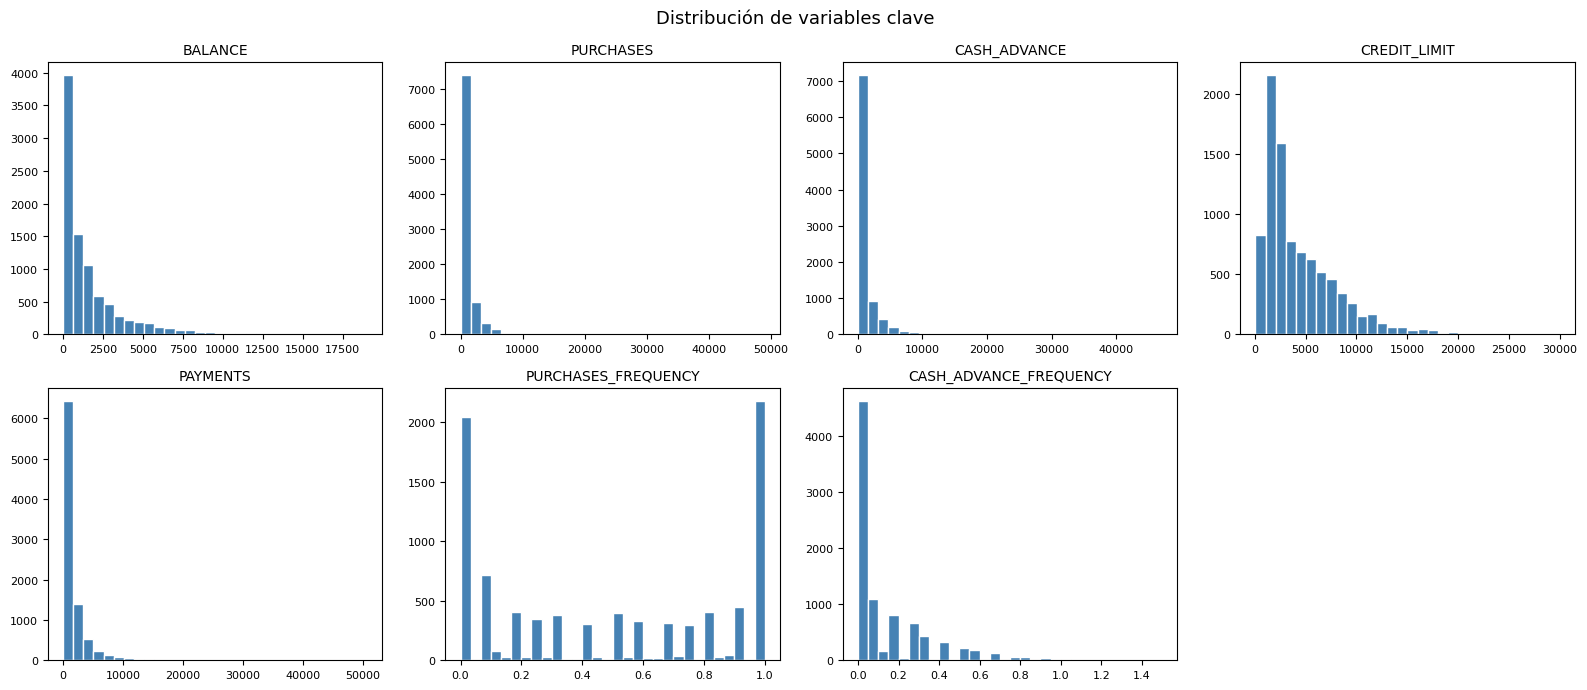

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(variablesclave):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribución de variables clave', fontsize=13)
plt.tight_layout()
plt.show()

Dandole un analisis a estas colas y sus grafica podemos concluir:
- Vemos que la cola va hacia la derecha indicandonos que la gran mayoria de clientes tienen un balance bajo es decir no tiene gran cantidad de deudas, mientras el numero del balance va aumentando hay menos clientes y muy pocos de ellos son los que tienen deudas muy grandes
- La gran mayoria realizan compras bajas
- La mayoria no saca avances en efectivo
- Realizan pagos en periodos variados y estos pagos la ,ayoria son bajos


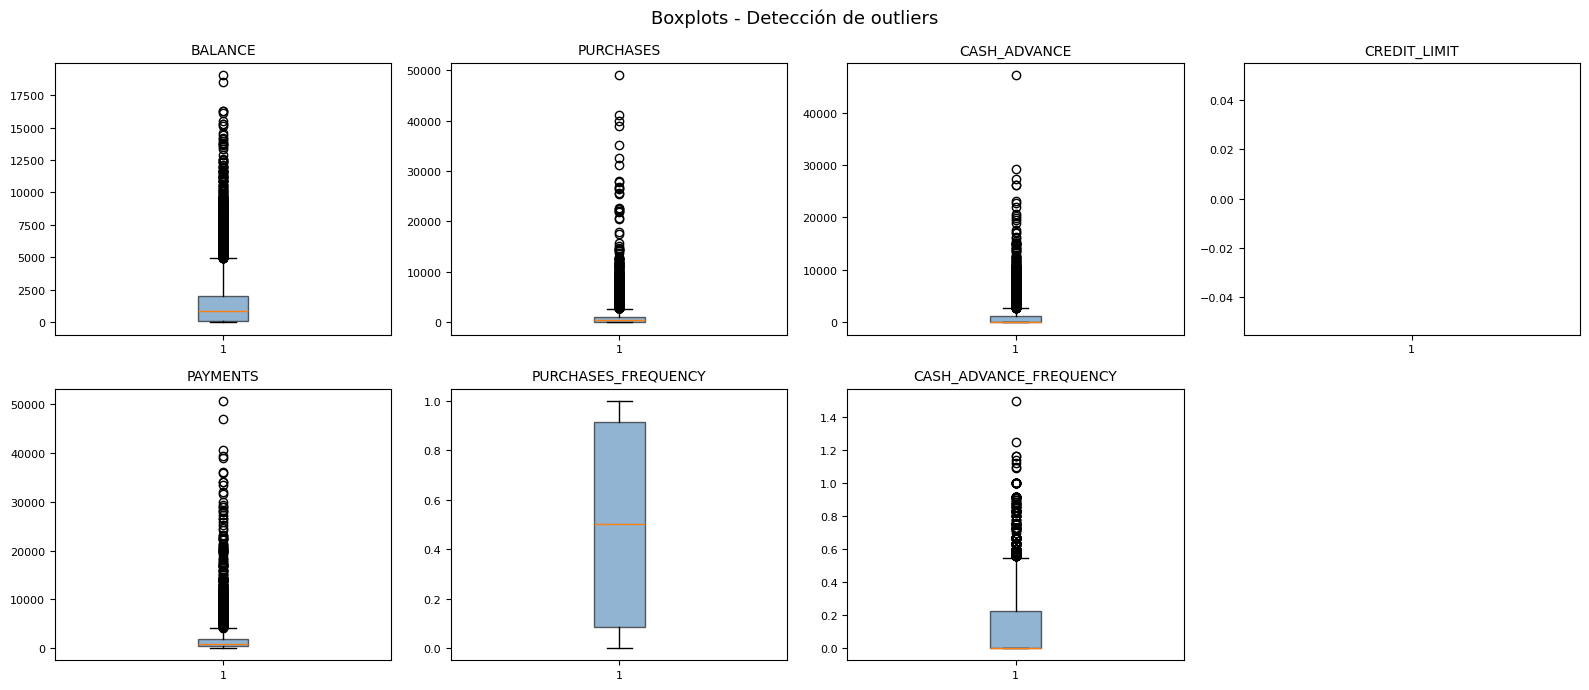

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(variablesclave):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)
plt.suptitle('Boxplots - Detección de outliers', fontsize=13)
plt.tight_layout()
plt.show()

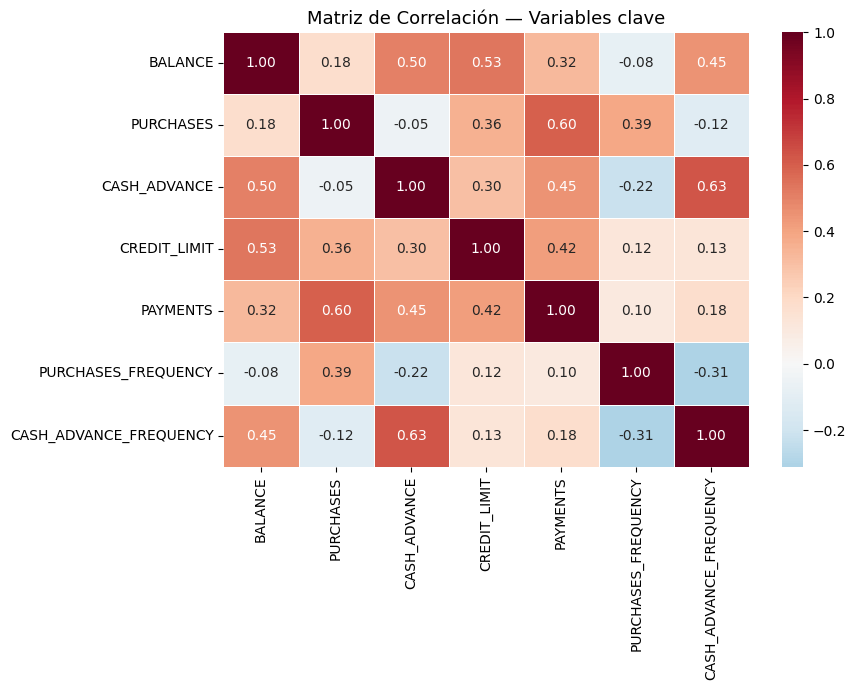

In [12]:
import seaborn as sns
# Heatmap
plt.figure(figsize=(9, 7))
corr = df_model.corr().round(2)

sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación — Variables clave', fontsize=13)
plt.tight_layout()
plt.show()

Aplicamos el metodo del codo para hallar la mejor K


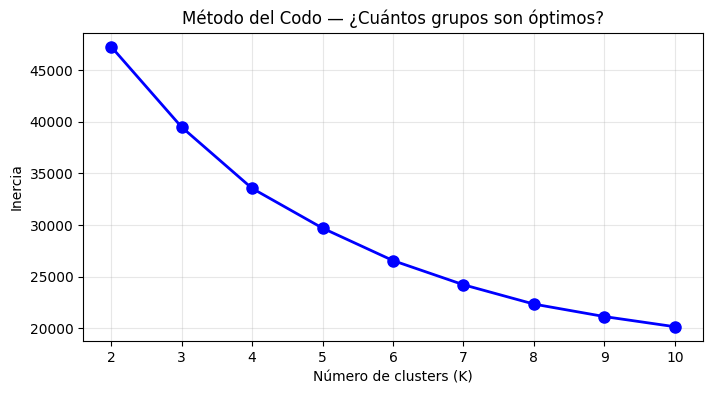

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo — ¿Cuántos grupos son óptimos?')
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

Comprobamos si k = 4 seria lo ideal


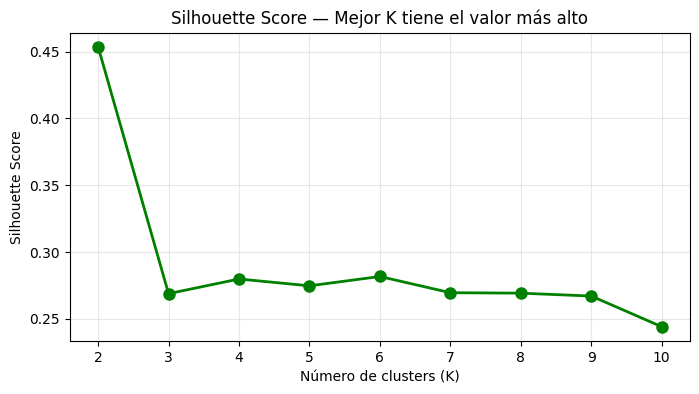

In [14]:
from sklearn.metrics import silhouette_score

silhouette = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    silhouette.append(silhouette_score(df_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(K, silhouette, 'go-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Mejor K tiene el valor más alto')
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

In [15]:
print("Evaluación de K-Means por número de clusters:")
print("-" * 45)
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"k={k}  |  Silhouette Score: {score:.3f}  |  Inercia: {km.inertia_:.2f}")

Evaluación de K-Means por número de clusters:
---------------------------------------------
k=2  |  Silhouette Score: 0.454  |  Inercia: 47276.97
k=3  |  Silhouette Score: 0.269  |  Inercia: 39487.58
k=4  |  Silhouette Score: 0.280  |  Inercia: 33553.80
k=5  |  Silhouette Score: 0.275  |  Inercia: 29703.24
k=6  |  Silhouette Score: 0.282  |  Inercia: 26561.19


Aplicamos K- means

In [16]:
# Aplicar K-Means con k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model = df_model.copy()
df_model['Cluster'] = km_final.fit_predict(df_scaled)

# Ver cuántos clientes quedaron en cada grupo
print("Clientes por grupo:")
print(df_model['Cluster'].value_counts().sort_index())

# Ver el promedio de las variables principales por grupo
cols_analisis = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
                 'CREDIT_LIMIT', 'PAYMENTS',
                 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

df_model.groupby('Cluster')[cols_analisis].mean().round(1)

Clientes por grupo:
Cluster
0    3808
1    3851
2    1157
3     133
Name: count, dtype: int64


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY
Cluster,,,,,,,
0,1052.1,221.6,686.7,2984.9,911.4,0.1,0.1
1,928.6,1438.9,170.7,4528.5,1481.4,0.9,0.0
2,5061.0,788.6,4620.8,8474.0,3844.3,0.4,0.5
3,4240.5,12642.4,1069.9,12108.3,14198.3,0.9,0.1


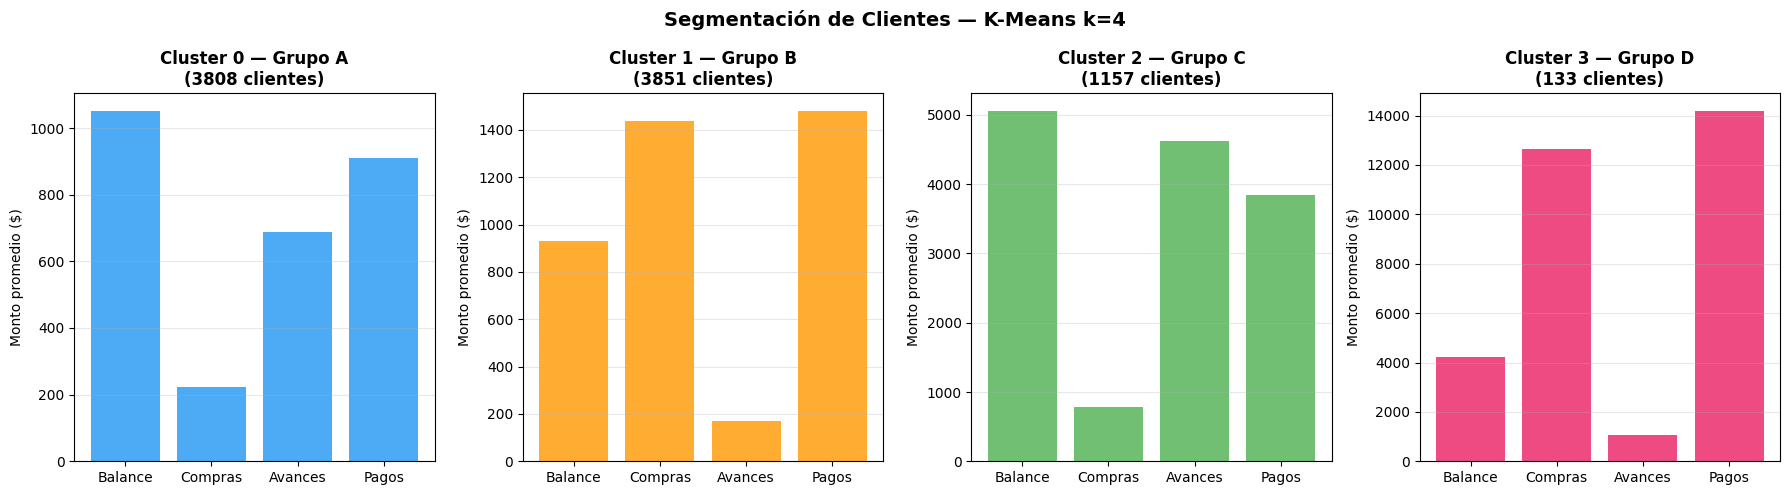

In [17]:
import numpy as np

# Gráfico de barras comparando los 4 grupos
resumen = df_model.groupby('Cluster')[cols_analisis].mean().round(1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
nombres = ['Grupo A', 'Grupo B', 'Grupo C', 'Grupo D']

for i, ax in enumerate(axes):
    valores = resumen.loc[i, ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']]
    ax.bar(['Balance', 'Compras', 'Avances', 'Pagos'],
           [valores['BALANCE'], valores['PURCHASES'],
            valores['CASH_ADVANCE'], valores['PAYMENTS']],
           color=colores[i], alpha=0.8)
    ax.set_title(f'Cluster {i} — {nombres[i]}\n({df_model["Cluster"].value_counts()[i]} clientes)',
                 fontweight='bold')
    ax.set_ylabel('Monto promedio ($)')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Segmentación de Clientes — K-Means k=4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Vemos que el modelo dividio en 4 grupos:
- Clientes Ahorradores que sacan avances en efectivo (3808 clientes): Clientes con un balance medio y uso moderado de los avances son el segmento mas grande, se recomienda requerir una evaluacion antes de ofrecer nuevos productos
- Clientes que son compradores activos (3851): Alto volumen de compras y buen comportamiento de pago, se recomienda que son los mejores candidatos
- Clientes de alto riesgo (1557): Balance elecado y alta dependencia a los avances efectivos No se recomienda ofrecer nuevos productos
- Clientes VIP (133): Solo representan el 1.5% de los clientes sus compras y pagos son sifnificativamente superiores del resto son los mejores candidatos, se recomienda crear un producto exclusivo





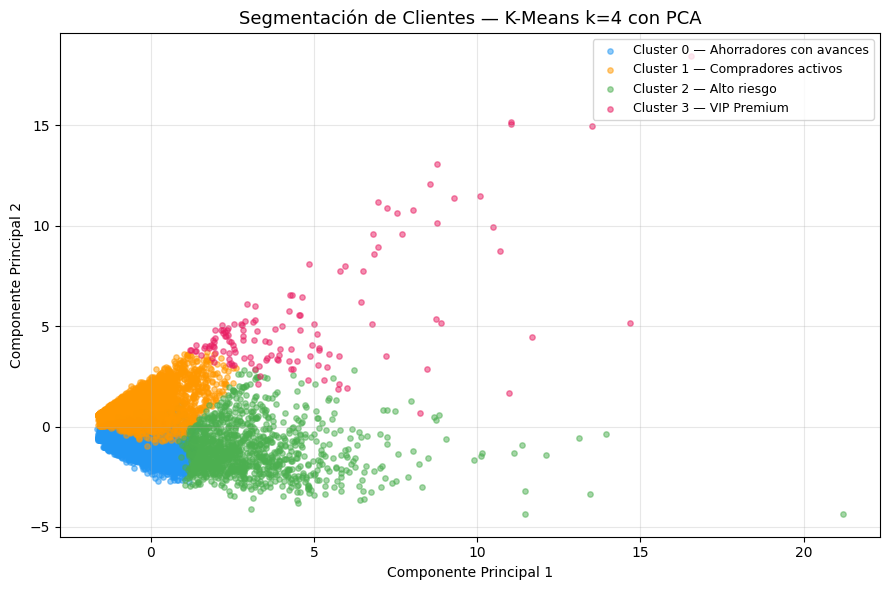

Varianza explicada por PCA: 65.6%


In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes = pca.fit_transform(df_scaled)


plt.figure(figsize=(9, 6))
colores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
nombres = ['Ahorradores con avances', 'Compradores activos', 'Alto riesgo', 'VIP Premium']

for i in range(4):
    mask = df_model['Cluster'] == i
    plt.scatter(componentes[mask, 0], componentes[mask, 1],
                c=colores[i], label=f'Cluster {i} — {nombres[i]}',
                alpha=0.5, s=15)

plt.title('Segmentación de Clientes — K-Means k=4 con PCA', fontsize=13)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

La segmentación en 4 grupos propuesta por el equipo de mercadeo
es razonable y está respaldada por las métricas de desempeño.
El método del codo muestra que a partir de K=4 la reducción
de inercia es marginal, y el Silhouette Score de K=4 (0.280)
es superior al de K=3 (0.269) y K=5 (0.275) dentro del
rango útil para el negocio.

Recomendacion estrategica
Enfocar la campaña de segunda tarjeta de crédito principalmente
en el Cluster 1 (compradores activos) por su volumen y
comportamiento de pago, y desarrollar una oferta premium
diferenciada para el Cluster 3 (VIP)